In [54]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from collections import Counter
import os


In [33]:
# Funciones utilizadas

def graficar_histograma(poblacion, color="deepskyblue", labelx="E",bins_auto=True,figsize=(10,6),savefig=False,filename="histograma.png"):
    """
    Genera un histograma de la población, mostrando la media con línea vertical.

    Parámetros
    ----------
    poblacion : array-like
        Datos numéricos (ej. distancias promedio).
    color : str, opcional
        Color de las barras del histograma.
    bins_auto : bool, opcional
        Si True, calcula los bins con la regla de Sturges (sqrt(n)),
        si False, deja que matplotlib decida.
    figsize : tuple, opcional
        Tamaño de la figura (ancho, alto).
    savefig : bool, opcional
        Si True, guarda la figura como archivo PNG.
    filename : str, opcional
        Nombre del archivo donde se guardará la figura.
    """

    poblacion = np.array(poblacion)

    media = np.mean(poblacion)
    desviacion = np.std(poblacion)
    rango = np.max(poblacion) - np.min(poblacion)

    if bins_auto:
        k = int(np.sqrt(len(poblacion)))  # número de intervalos
        h = rango / k if k > 0 else 1
        bins = np.arange(np.min(poblacion), np.max(poblacion) + h, h)
    else:
        bins = "auto"

    print(f"Media: {media:.4f}")
    print(f"Desviación estándar: {desviacion:.4f}")

    plt.figure(figsize=figsize)
    plt.hist(poblacion, bins=bins, color=color, alpha=0.6,
             label="Datos", edgecolor="black")
    plt.axvline(media, color="red", label=f"$\\mu$={media:.4f}")
    plt.legend()
    plt.xlabel(labelx)
    plt.ylabel("Frecuencia")
    if savefig:
        plt.savefig(filename)
        

    plt.show()

def graficar_dispersion_umbral(df_norm, dfNombresplanetas, columna,
                               umbral=0.25, color="red",
                               figsize=(10,6),
                               savefig=False,
                               filename="dispersion.png",):
    """
    Genera una gráfica de dispersión de una columna con un umbral,
    mostrando los puntos filtrados y sus etiquetas.

    Parámetros
    ----------
    df_norm : DataFrame
        DataFrame con los datos normalizados.
    dfNombresplanetas : Series o array-like
        Nombres asociados a cada fila (ej. nombres de planetas).
    columna : str
        Nombre de la columna a graficar.
    umbral : float, opcional
        Valor mínimo para filtrar los datos.
    color : str, opcional
        Color de los puntos.
    figsize : tuple, opcional
        Tamaño de la figura.
    savefig : bool, opcional
        Si True, guarda las figuras como archivos PNG.
    filename : str, opcional
        Nombre del archivo donde se guardará la figura.
    """

    # Datos
    y = df_norm[columna]
    x = range(len(y))

    # Filtrado
    y_filter = y[y > umbral]
    x_filter = range(len(y_filter))

    print(f"Columna: {columna}")
    print(f"Cantidad total: {len(y)}")
    print(f"Cantidad > umbral ({umbral}): {len(y_filter)}")

    # -------- Gráfica general --------
    plt.figure(figsize=figsize)
    plt.scatter(x, y.values, color=color, alpha=0.2)
    plt.axhline(y=umbral, color='black', linestyle='--')
    plt.ylabel(columna)

    if savefig:
        plt.savefig(f"{filename}_general.png")

    plt.show()

    # Mostrar nombres filtrados
    nombres_filtrados = dfNombresplanetas[y_filter.index]
    print("\nElementos que superan el umbral:")
    print(nombres_filtrados)

    # -------- Gráfica filtrada --------
    plt.figure(figsize=figsize)
    plt.scatter(x_filter, y_filter.values, color=color)

    # Etiquetas
    for i, txt in enumerate(nombres_filtrados):
        plt.annotate(txt, (x_filter[i], y_filter.values[i]), rotation=15)

    plt.ylabel(columna)

    if savefig:
        plt.savefig(filename)

    plt.show()


# Base de datos y preprocesamiento

Se importan el conjunto de datos proveniente de [https://exoplanetarchive.ipac.caltech.edu/docs/data.html ](https://exoplanetarchive.ipac.caltech.edu/docs/data.html). En dicha liga nos dirigimos a "planetary systems" y se filtran aquellos datos que no cuenten con información de: 

1. periodo orbital (pl_orbper)
2. radio planetario (pl_rade)
3. excentricidad (pl_orbeccen)
4. temperatura en equilibrio (pl_eqt)
5. masa estelar (st_mass)
6. gravedad estelar en superficie (st_logg)
7. distancia a la estrella (sy_dist)


In [15]:
# Cargar el dataset
df=pd.read_csv("exoplanetas.csv",comment="#")
df.head()

,loc_rowid,pl_name,pl_orbper,pl_rade,pl_masse,pl_orbeccen,pl_eqt,st_mass,st_metratio,st_logg,sy_dist
0,1,11 Com b,323.21000,NaN,NaN,0.238,NaN,2.09,[Fe/H],2.45,93.1846
1,2,11 Com b,326.03000,NaN,NaN,0.231,NaN,2.70,[Fe/H],2.31,93.1846
2,3,11 Com b,NaN,NaN,NaN,NaN,NaN,2.60,NaN,NaN,93.1846
3,4,11 UMi b,516.22000,NaN,NaN,0.080,NaN,1.80,[Fe/H],1.60,125.3210
4,5,11 UMi b,516.21997,NaN,NaN,0.080,NaN,2.78,[Fe/H],1.93,125.3210


In [16]:
# Retirar columnas 
df = df.drop('pl_masse', axis=1)
df = df.drop('st_metratio', axis=1)


In [17]:
#Revisar si hay columnas con datos nulos
df.isna().sum()


loc_rowid          0
pl_name            0
pl_orbper       3271
pl_rade        12130
pl_orbeccen    20404
pl_eqt         21971
st_mass         6038
st_logg         8705
sy_dist          844
dtype: int64

In [18]:
# Eliminamos datos nulos
df_clean = df.dropna()
len(df_clean)
print("Numero de planetas en el dataset limpio: ", len(df_clean))


Numero de planetas en el dataset limpio:  14037


In [19]:
# Obtenemos el nombre de los planetas y los datos en dataframes separados
dfNombresplanetas=df_clean['pl_name']
# Dataframe numerico
df_clean = df_clean.drop(['pl_name',"loc_rowid"], axis=1)
df_clean
# Normalizamos los datos
df_norm=(df_clean - df_clean.min()) / (df_clean.max() - df_clean.min())
df_norm

,pl_orbper,pl_rade,pl_orbeccen,pl_eqt,st_mass,st_logg,sy_dist
110,0.000153,0.000423,0.066304,0.467047,0.232672,0.428029,0.001753
177,0.002270,0.000861,0.006272,0.121086,0.119068,0.420436,0.000924
188,0.005118,0.000526,0.003674,0.085165,0.119068,0.420436,0.000924
208,0.011372,0.000458,0.000000,0.107329,0.248778,0.436283,0.050067
233,0.001126,0.004978,0.071739,0.478002,0.377912,0.328986,0.168760
...,...,...,...,...,...,...,...
38958,0.001098,0.002921,0.000000,0.281584,0.271498,0.411522,0.078078
38972,0.000982,0.005355,0.000000,0.369984,0.395168,0.360350,0.066285
38976,0.000735,0.003530,0.041304,0.412274,0.376474,0.394355,0.065900
39066,0.001668,0.000418,0.000000,0.260439,0.265746,0.413173,0.003399


# Análisis exploratorio

In [41]:
# Configurando lista de colores para los histogramas
colores=['red','deepskyblue','lime','yellow','orange','purple','pink']
# Creando carpeta para guardar las imagenes

if not os.path.exists("Imagenes"):
    os.makedirs("Imagenes")
if not os.path.exists("Imagenes/Histogramas"):
    os.makedirs("Imagenes/Histogramas")
if not os.path.exists("Imagenes/Dispersion"):
    os.makedirs("Imagenes/Dispersion")


Media: 0.0071
Desviación estándar: 0.0169


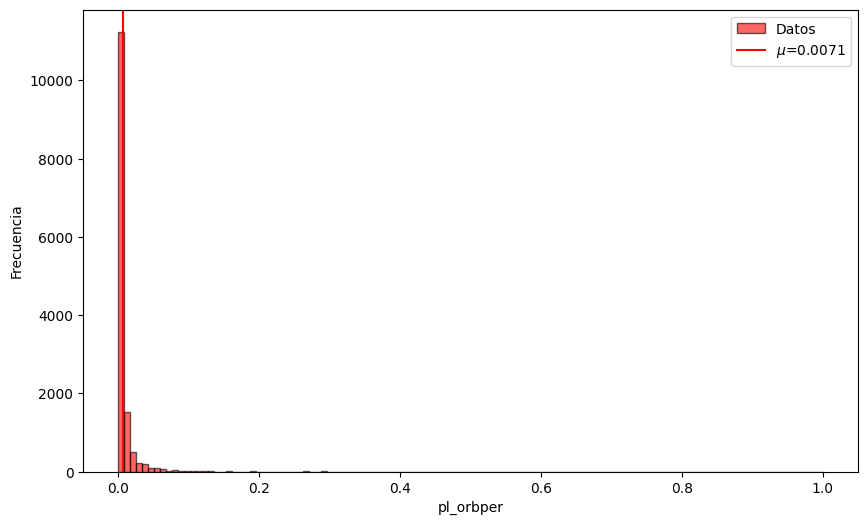

Media: 0.0013
Desviación estándar: 0.0215


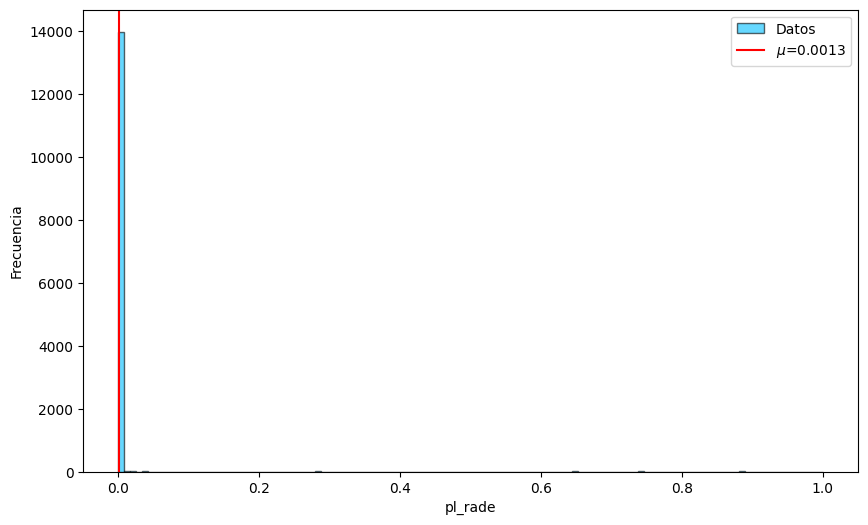

Media: 0.0093
Desviación estándar: 0.0536


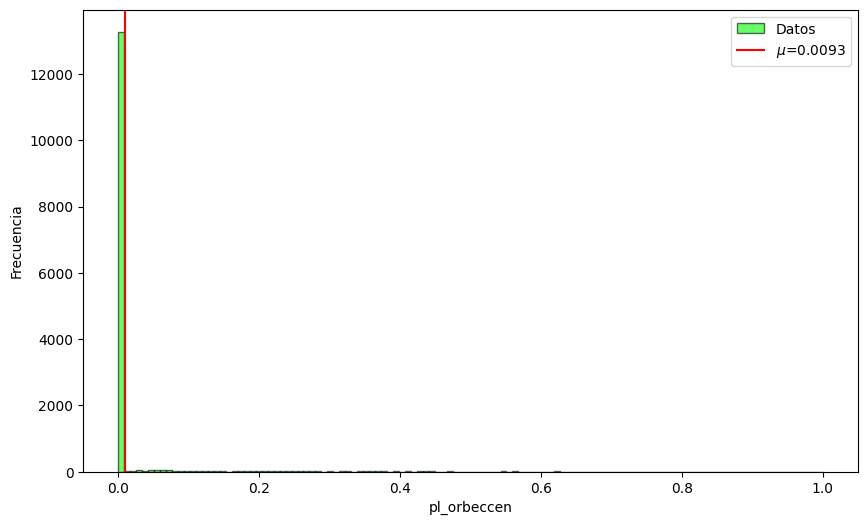

Media: 0.1869
Desviación estándar: 0.1016


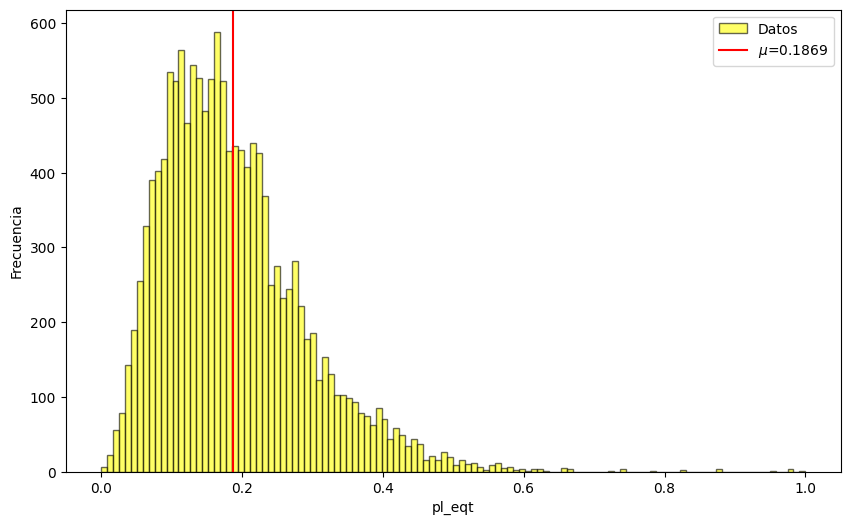

Media: 0.2423
Desviación estándar: 0.0632


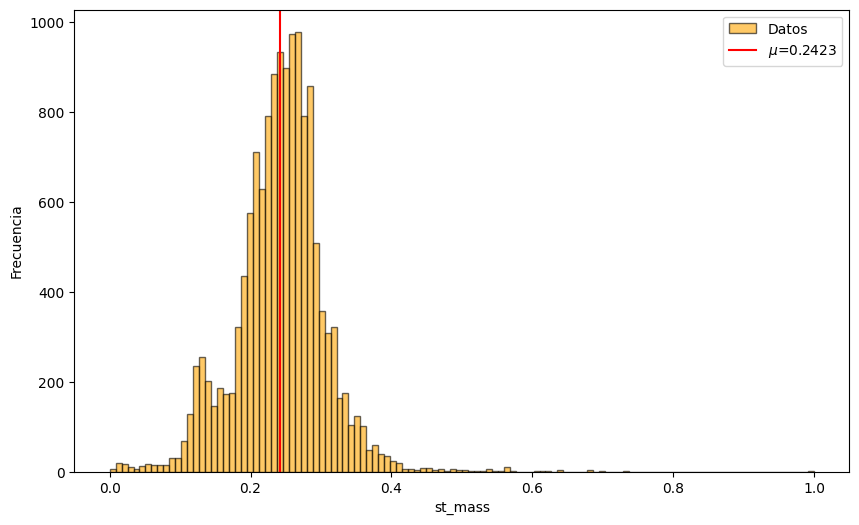

Media: 0.4266
Desviación estándar: 0.0368


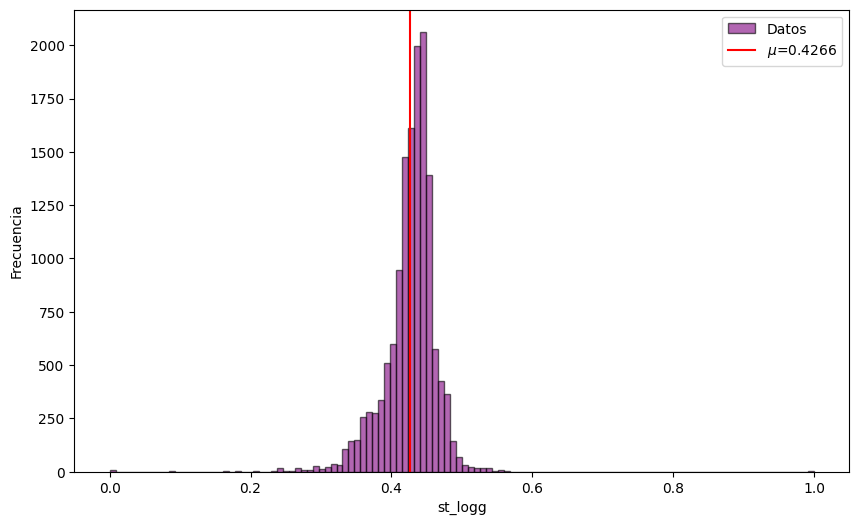

Media: 0.2208
Desviación estándar: 0.1334


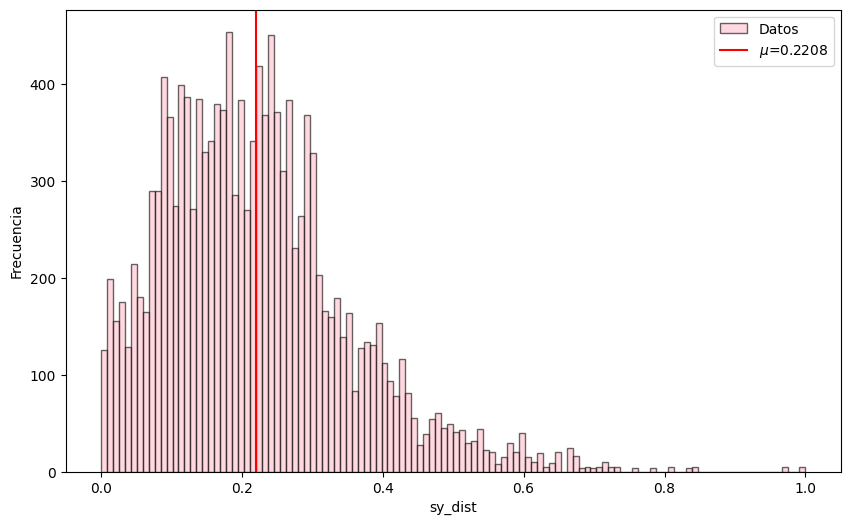

In [30]:
# Generando histogramas para cada variable
for i, columna in enumerate(df_norm.columns):
    graficar_histograma(df_norm[columna], color=colores[i % len(colores)], labelx=columna,savefig=True,filename=f"Imagenes/Histogramas/histograma_{columna}.png")
    

In [43]:
df_norm.columns

Index(['pl_orbper', 'pl_rade', 'pl_orbeccen', 'pl_eqt', 'st_mass', 'st_logg',
       'sy_dist'],
      dtype='object')

Columna: pl_orbper
Cantidad total: 14037
Cantidad > umbral (0.25): 10


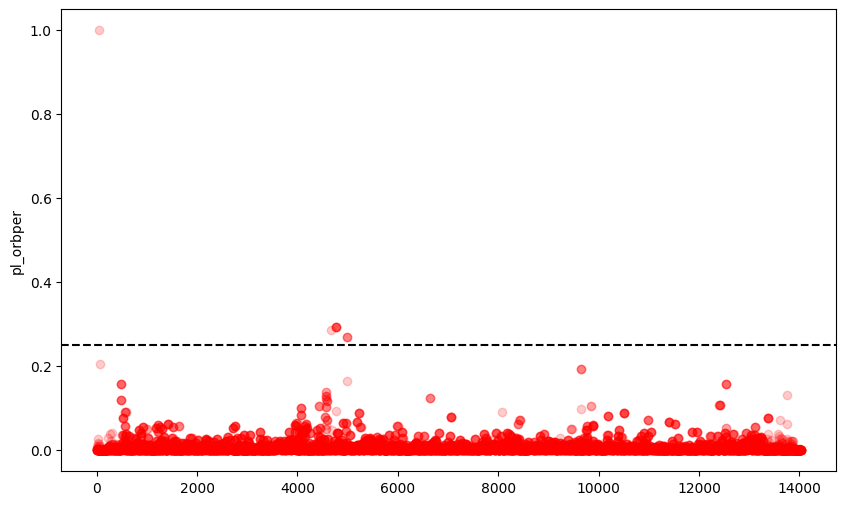


Elementos que superan el umbral:
529      EPIC 248847494 b
15709       Kepler-1654 b
15902        Kepler-167 e
15905        Kepler-167 e
15907        Kepler-167 e
15908        Kepler-167 e
15909        Kepler-167 e
16297       Kepler-1704 b
16299       Kepler-1704 b
16300       Kepler-1704 b
Name: pl_name, dtype: object


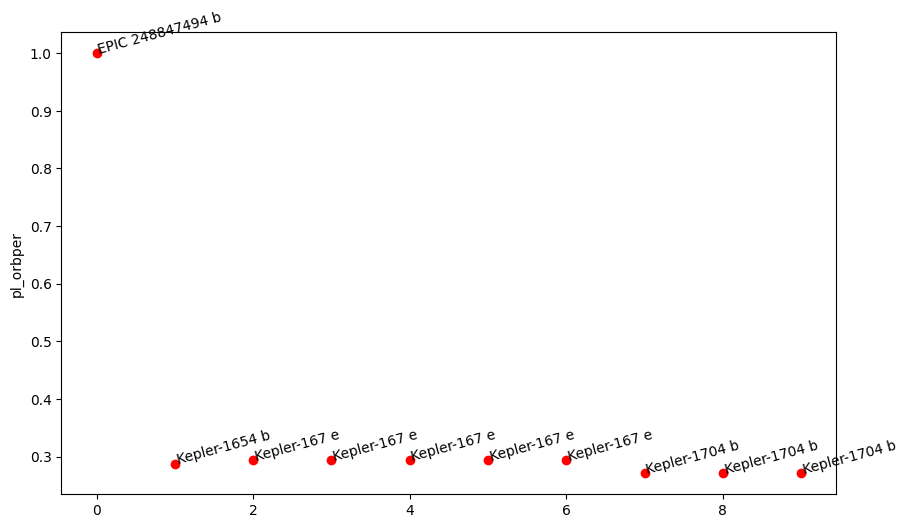

Columna: pl_rade
Cantidad total: 14037
Cantidad > umbral (0.2): 13


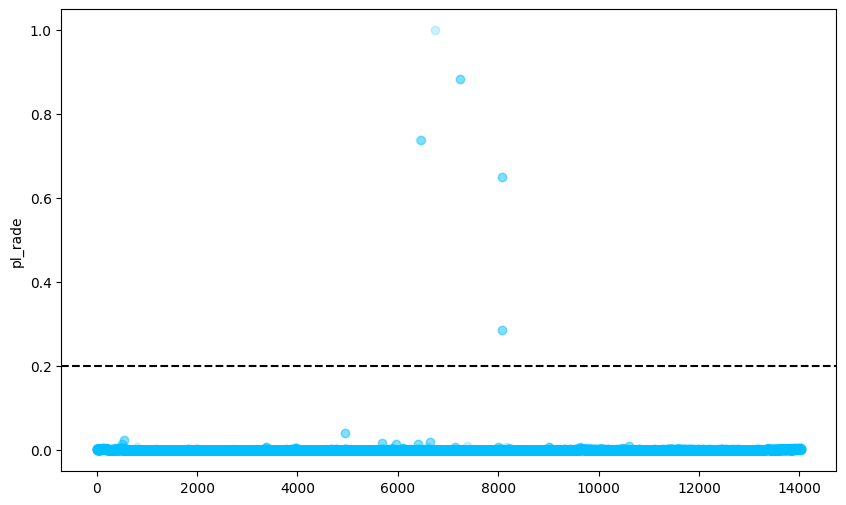


Elementos que superan el umbral:
19036    Kepler-1946 b
19037    Kepler-1946 b
19041    Kepler-1946 b
19592    Kepler-1999 b
20775     Kepler-230 b
20779     Kepler-230 b
20781     Kepler-230 b
22874      Kepler-29 b
22875      Kepler-29 b
22876      Kepler-29 b
22885      Kepler-29 c
22889      Kepler-29 c
22894      Kepler-29 c
Name: pl_name, dtype: object


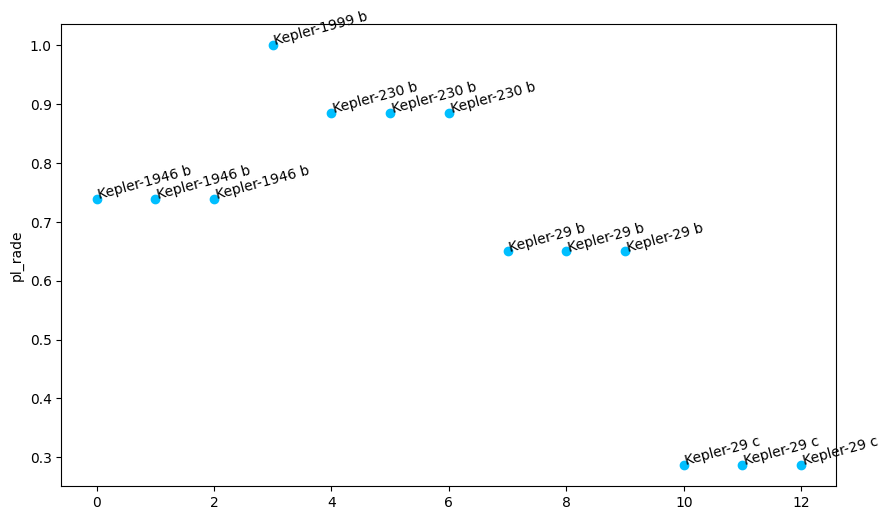

Columna: pl_orbeccen
Cantidad total: 14037
Cantidad > umbral (0.8): 5


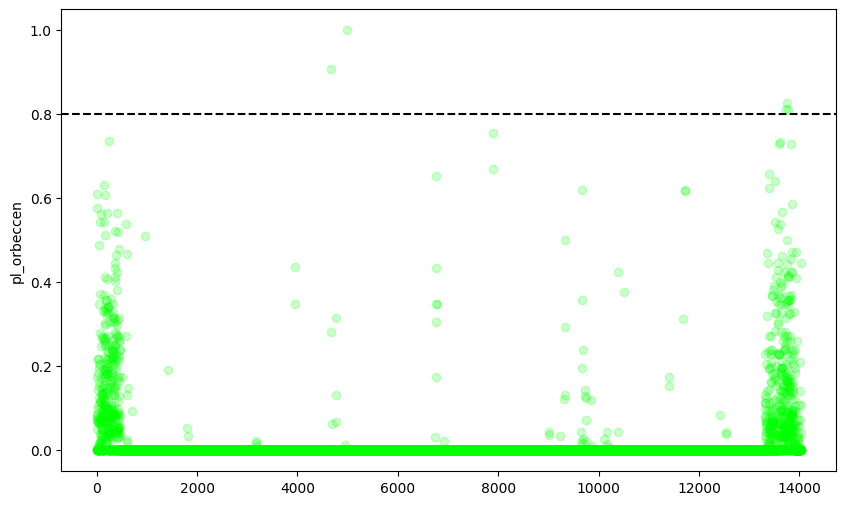


Elementos que superan el umbral:
15724    Kepler-1656 b
16299    Kepler-1704 b
36867       TOI-4127 b
36957       TOI-4562 b
37018       TOI-5110 b
Name: pl_name, dtype: object


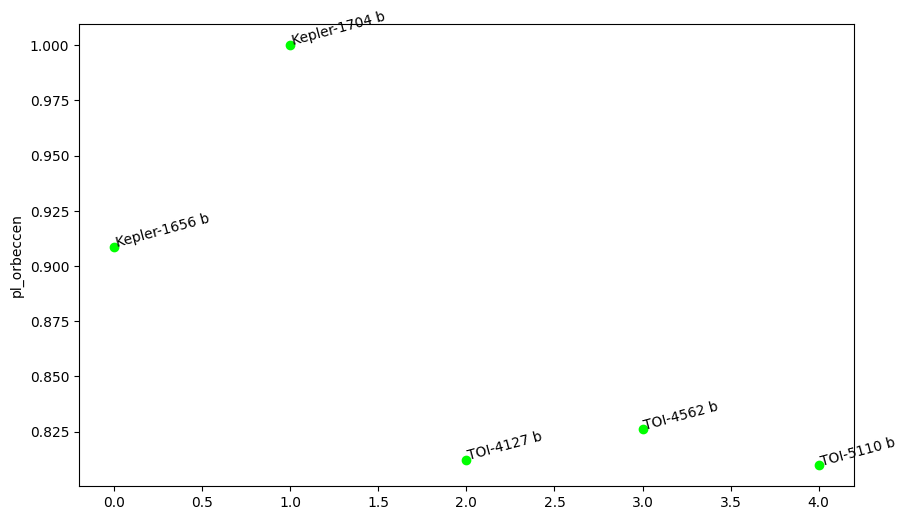

In [45]:
umbrales = [0.25, 0.2, 0.8]
columnas=['pl_orbper','pl_rade',"pl_orbeccen"]
for i, columna in enumerate(columnas):
    graficar_dispersion_umbral(
        df_norm,
        dfNombresplanetas,
        columna,
        umbral=umbrales[i],
        color=colores[i % len(colores)],
        savefig=True,
        filename=f"Imagenes/Dispersion/dispersion_{columna}.png"
    )

# Detección de anomalias


# Isolation Forest

In [55]:
if not os.path.exists("Imagenes/DeteccionAnomalias"):
    os.makedirs("Imagenes/DeteccionAnomalias")

In [63]:
n_trees=200
list_trees=[2,5,10,25,50,100,200]
AnomaliasDetectadas=[]
X=df_norm
for n_trees in list_trees:
  print("n_trees: ",n_trees)
  clf = IsolationForest(n_estimators=n_trees, random_state=42)
  clf.fit(X)
  y_pred = clf.predict(X)

  df_norm["scoreIF"] = clf.decision_function(X)
  df_norm["claseIF"] = y_pred  # -1 = outlier, 1 = inlier
  AnomaliasDetectadas.append(len(df_norm[df_norm["claseIF"]==-1]))

n_trees:  2
n_trees:  5
n_trees:  10
n_trees:  25
n_trees:  50
n_trees:  100
n_trees:  200


Text(29.597222222222214, 0.5, 'Número de anomalias')

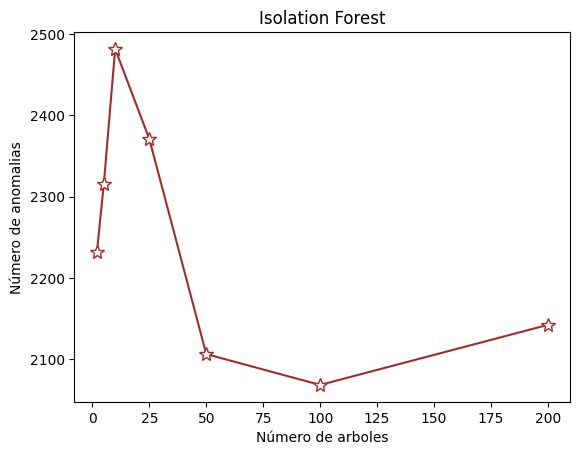

In [64]:
plt.plot(list_trees,AnomaliasDetectadas,marker="*",markerfacecolor="white",markersize=10,color="Brown")
plt.savefig("Imagenes/DeteccionAnomalias/Anomalias_vs_Trees.png")
plt.title("Isolation Forest")
plt.xlabel("Número de arboles")
plt.ylabel("Número de anomalias")